# Projet REXIA -- Responsible and Explainable AI

## Partie 1/3 : Donnees tabulaires

Analyse du jeu de donnees RH anonymise. La variable cible `label` indique :
- **0** : l'employe n'a pas demissionne dans les 6 prochains mois
- **1** : l'employe a demissionne dans les 6 prochains mois

## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -- Configuration globale des graphiques --
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
DATA_PATH = "../data/RH_dataset.csv"
CSV_SEPARATOR = ";"

LABEL_COL = "label"
LABEL_NAMES = {0: "Non-demission", 1: "Demission"}

## Fonctions utilitaires

In [2]:
def load_dataset(path: str, separator: str = ";") -> pd.DataFrame:
    """Charge le jeu de donnees CSV et retourne un DataFrame."""
    return pd.read_csv(path, sep=separator)

def display_summary_table(data: pd.DataFrame) -> pd.DataFrame:
    """Retourne un DataFrame recapitulatif : type, nb valeurs uniques, min, max, manquantes."""
    summary = pd.DataFrame({
        "Type": data.dtypes,
        "Valeurs uniques": data.nunique(),
        "Valeurs manquantes": data.isnull().sum(),
        "% manquantes": (data.isnull().sum() / len(data) * 100).round(2),
        "Exemple": data.iloc[0],
    })
    return summary

# Chargement du dataset

In [3]:
df = load_dataset(DATA_PATH, CSV_SEPARATOR)

print(f"Dimensions du jeu de donnees : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")
df.head(10)

Dimensions du jeu de donnees : 23857 lignes, 14 colonnes



,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0
5,Production,30.410000,29.049999,3.350000,4.290000,28,40,1,1,3510,PACS,1,2642,0
6,Commercial/Business,13.840000,32.410000,8.890000,42.509998,28,72,1,3,7223,Marié(e),1,318,0
7,Etudes & Technique,34.799999,22.790001,9.480000,10.580000,28,45,1,2,4132,Marié(e),1,2132,0
8,Etudes & Technique,80.220001,24.180000,8.090000,35.349998,28,65,0,2,4773,Divorcé(e),1,880,0
9,Etudes & Technique,5.190000,2.780000,1.420000,10.100000,28,42,0,2,4517,Union libre,1,676,0


In [4]:
!pip install imblearn

   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   ---------------------- ----------------- 133.1/235.4 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 235.4/235.4 kB 3.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 3. Apprentissage automatique

*(A completer lors de la prochaine seance.)*

Pistes prevues :
- Pre-traitement des donnees (encodage des variables categorielles, normalisation, gestion du desequilibre)
- Entrainement de modeles (regression logistique, arbre de decision, random forest, etc.)
- Evaluation avec des metriques adaptees au desequilibre (F1-score, AUC-ROC, matrice de confusion)
- Analyse de l'equite (fairness metrics) sur les groupes sensibles identifies en partie 2
- Explicabilite des predictions (SHAP, LIME)

### 3.1 Pipeline de prétraitement et gestion du déséquilibre

Nous utilisons un `ColumnTransformer` pour :
- Standardiser les variables numériques et ordinales/binaires (`StandardScaler`).
- Encoder les variables catégorielles nominales (`OneHotEncoder`).

Enfin, pour compenser la forte asymétrie de la variable cible (3.2% de démissions), nous appliquons la méthode **SMOTE** (Synthetic Minority Over-sampling Technique) sur le jeu d'entraînement.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

# 0. Conservation de la dernière ligne par individu
# On trie d'abord par matricule et ancienneté pour s'assurer que la dernière ligne est la plus récente
df_unique = df.sort_values(by=['matricule', 'Ancienneté groupe (années)']).drop_duplicates(subset=['matricule'], keep='last')
print(f"Dimensions avant dédoublonnage : {df.shape}")
print(f"Dimensions après dédoublonnage : {df_unique.shape}\n")

# 1. Séparation train/test (stratifiée)
X = df_unique.drop(columns=[LABEL_COL])
y = df_unique[LABEL_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Dimensions Train : {X_train.shape}, Test : {X_test.shape}")

# 2. Pipeline de prétraitement
# Etablissement a 35 catégories distinctes ; Famille d'emploi en a 8
categorical_features = ["Famille d'emploi", "Etablissement", 'Statut marital']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 3. Application du prétraitement
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# 4. Gestion du déséquilibre avec SMOTE (sur le Train uniquement)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

print(f"\nRépartition target AVANT SMOTE:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Répartition target APRÈS SMOTE:\n{y_train_resampled.value_counts(normalize=True).round(3)}")
print(f"Nouvelles dimensions Train (après SMOTE) : X={X_train_resampled.shape}, y={y_train_resampled.shape}")

Dimensions avant dédoublonnage : (23857, 14)
Dimensions après dédoublonnage : (2676, 14)

Dimensions Train : (2140, 13), Test : (536, 13)

Répartition target AVANT SMOTE:
label
0    0.848
1    0.152
Name: proportion, dtype: float64
Répartition target APRÈS SMOTE:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Nouvelles dimensions Train (après SMOTE) : X=(3628, 62), y=(3628,)


In [10]:
X_test_preprocessed[:5]

array([[ 0.99468025,  3.66154445, -0.30934184, -0.61102605, -0.0843954 ,
         0.69869738, -0.87263871, -0.64606085, -1.05082609,  1.58038618,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [-1.09377733, -0.91515012,  0.22110782, -0.05903532,  0.088599  ,
         0.69869

### 3.2.1 Entraînement — Random Forest

Nous entraînons une **Random Forest** sur les données rééchantillonnées. C'est un bon point de départ : robuste au bruit, peu sensible aux hyperparamètres par défaut, et interprétable via l'importance des variables.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

# --- Entraînement ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_resampled, y_train_resampled)
print("Entraînement terminé.")

Entraînement terminé.


### 3.2.2 Évaluation du modèle

On évalue sur le jeu de test (non touché par SMOTE ni par le fit du preprocesseur). Métriques prioritaires pour un problème déséquilibré : **F1-score**, **AUC-ROC**, et la **matrice de confusion**.

=== Rapport de classification ===
               precision    recall  f1-score   support

Non-demission       0.91      0.92      0.91       454
    Demission       0.53      0.51      0.52        82

     accuracy                           0.85       536
    macro avg       0.72      0.71      0.72       536
 weighted avg       0.85      0.85      0.85       536

AUC-ROC : 0.8281


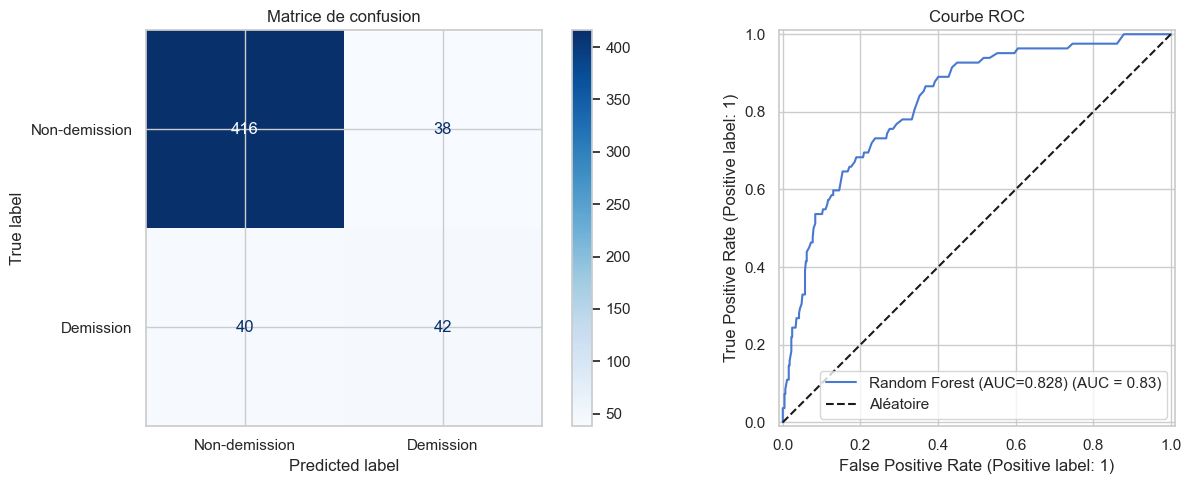

In [14]:
y_pred = rf.predict(X_test_preprocessed)
y_proba = rf.predict_proba(X_test_preprocessed)[:, 1]

# --- Rapport de classification ---
print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=list(LABEL_NAMES.values())))

# --- AUC-ROC ---
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC : {auc:.4f}")

# --- Matrice de confusion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=list(LABEL_NAMES.values()),
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=f"Random Forest (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2.3 Importance des variables

La Random Forest fournit nativement une importance des variables (basée sur la réduction d'impureté de Gini). Cela donne un premier aperçu des features les plus discriminantes.

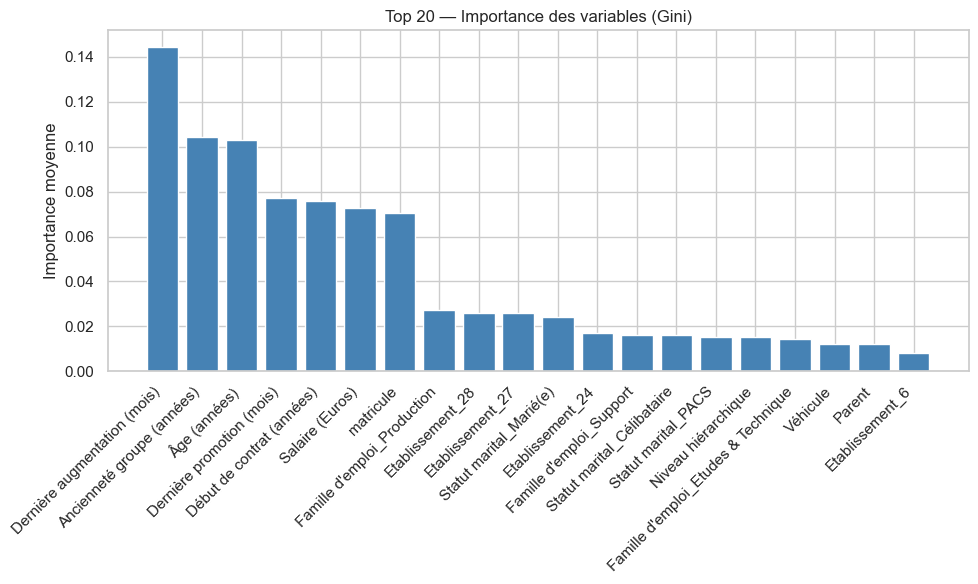

In [15]:
# Récupération des noms de features après OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(ohe_feature_names)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 20

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), importances[indices[:top_n]], color="steelblue")
plt.xticks(range(top_n), [all_feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.title(f"Top {top_n} — Importance des variables (Gini)")
plt.ylabel("Importance moyenne")
plt.tight_layout()
plt.show()

---
### 3.3 Régression Logistique

La **régression logistique** est un modèle linéaire de classification. Malgré sa simplicité, elle offre une bonne interprétabilité via les coefficients (odds-ratios) et constitue une baseline solide pour comparer les modèles plus complexes.

On l'entraîne ici avec régularisation L2 (par défaut) sur les données rééchantillonnées par SMOTE.

In [ ]:
from sklearn.linear_model import LogisticRegression

# --- Entraînement ---
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr.fit(X_train_resampled, y_train_resampled)
print("Entraînement terminé.")

# --- Évaluation ---
y_pred_lr = lr.predict(X_test_preprocessed)
y_proba_lr = lr.predict_proba(X_test_preprocessed)[:, 1]

print("\n=== Rapport de classification — Régression Logistique ===")
print(classification_report(y_test, y_pred_lr, target_names=list(LABEL_NAMES.values())))

auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"AUC-ROC : {auc_lr:.4f}")

# --- Visualisations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=list(LABEL_NAMES.values()),
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion — Régression Logistique")

RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=axes[1],
                                  name=f"Régression Logistique (AUC={auc_lr:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

NameError: name 'X_train_resampled' is not defined

In [ ]:
# --- Coefficients les plus importants ---
coefs = lr.coef_[0]
indices_lr = np.argsort(np.abs(coefs))[::-1]
top_n = 20

plt.figure(figsize=(10, 6))
colors = ["tomato" if coefs[i] < 0 else "steelblue" for i in indices_lr[:top_n]]
plt.bar(range(top_n), coefs[indices_lr[:top_n]], color=colors)
plt.xticks(range(top_n), [all_feature_names[i] for i in indices_lr[:top_n]], rotation=45, ha='right')
plt.title(f"Top {top_n} — Coefficients de la Régression Logistique")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

---
### 3.4 Generalized Additive Model (GAM)

Un **GAM** (Modèle Additif Généralisé) étend la régression logistique en remplaçant les termes linéaires par des fonctions lisses non-linéaires de chaque feature :

$$\log\frac{p}{1-p} = \beta_0 + f_1(x_1) + f_2(x_2) + \cdots + f_p(x_p)$$

Il conserve ainsi l'**interprétabilité par variable** (shape functions) tout en capturant des effets non-linéaires.

On utilise la librairie **`pygam`** avec un `LogisticGAM`.

In [ ]:
!pip install pygam -q

In [ ]:
from pygam import LogisticGAM, s, f

# Construction des termes : spline pour chaque feature numérique, facteur pour OHE
n_num = len(numerical_features)
n_cat_ohe = X_train_resampled.shape[1] - n_num

terms = s(0)
for i in range(1, n_num):
    terms += s(i)
for i in range(n_num, n_num + n_cat_ohe):
    terms += f(i)

# --- Entraînement avec recherche automatique du lissage (gridsearch) ---
gam = LogisticGAM(terms).gridsearch(X_train_resampled, y_train_resampled)
print("Entraînement GAM terminé.")

In [ ]:
y_pred_gam = (gam.predict_proba(X_test_preprocessed) >= 0.5).astype(int)
y_proba_gam = gam.predict_proba(X_test_preprocessed)

print("=== Rapport de classification — GAM ===")
print(classification_report(y_test, y_pred_gam, target_names=list(LABEL_NAMES.values())))

auc_gam = roc_auc_score(y_test, y_proba_gam)
print(f"AUC-ROC : {auc_gam:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gam,
    display_labels=list(LABEL_NAMES.values()),
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matrice de confusion — GAM")

RocCurveDisplay.from_predictions(y_test, y_proba_gam, ax=axes[1],
                                  name=f"GAM (AUC={auc_gam:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Shape functions des variables numériques (top 6) ---
# Les shape functions montrent l'effet partiel f_i(x_i) de chaque variable sur le log-odds
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    XX = gam.generate_X_grid(term=idx)
    pdep, confi = gam.partial_dependence(term=idx, X=XX, width=0.95)
    ax.plot(XX[:, idx], pdep, color="steelblue", lw=2)
    ax.fill_between(XX[:, idx], confi[:, 0], confi[:, 1], alpha=0.2, color="steelblue")
    ax.axhline(0, color='k', linestyle='--', lw=0.8)
    ax.set_title(f"Shape function : {numerical_features[idx]}", fontsize=10)
    ax.set_xlabel(numerical_features[idx])
    ax.set_ylabel("Effet partiel (log-odds)")

plt.suptitle("GAM — Shape functions des variables numériques (top 6)", fontsize=13)
plt.tight_layout()
plt.show()

### 3.5 Comparaison des modèles

| Modèle | AUC-ROC |
|---|---|
| Random Forest | `auc_rf` |
| Régression Logistique | `auc_lr` |
| GAM | `auc_gam` |

In [ ]:
results = pd.DataFrame({
    "Modèle": ["Random Forest", "Régression Logistique", "GAM"],
    "AUC-ROC": [auc, auc_lr, auc_gam]
}).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(results["Modèle"], results["AUC-ROC"], color=["steelblue", "seagreen", "tomato"])
plt.xlim(0.5, 1.0)
plt.xlabel("AUC-ROC")
plt.title("Comparaison des modèles — AUC-ROC")
for i, v in enumerate(results["AUC-ROC"]):
    plt.text(v + 0.002, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.show()